In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))
warnings.filterwarnings("ignore")


import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_catboost_tuning, run_lgbm_tuning, run_lr_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Income](https://www.openml.org/search?type=data&status=active&id=1590)

In [2]:
dataset_id = 1590
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
metrics_lr = bootstrap_metrics(y_test, y_pred_lr, y_prob_lr)

[I 2025-04-21 17:49:21,336] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-21 17:49:21,559] Trial 0 finished with value: 0.8958725636532564 and parameters: {'penalty': 'l1', 'C': 0.01}. Best is trial 0 with value: 0.8958725636532564.
[I 2025-04-21 17:49:21,752] Trial 1 finished with value: 0.9036257793501111 and parameters: {'penalty': 'l2', 'C': 10}. Best is trial 1 with value: 0.9036257793501111.
[I 2025-04-21 17:49:21,826] Trial 2 finished with value: 0.8761313295291625 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 1 with value: 0.9036257793501111.
[I 2025-04-21 17:49:22,161] Trial 3 finished with value: 0.9032673542657881 and parameters: {'penalty': 'l1', 'C': 100}. Best is trial 1 with value: 0.9036257793501111.
[I 2025-04-21 17:49:25,027] Trial 4 finished with value: 0.9033329619401824 and parameters: {'penalty': 'l1', 'C': 10}. Best is trial 1 with value: 0.9036257793501111.
[I 2025-04-21 17:49:25,233] Trial 5 finished with v

In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb  = model_cb.predict(X_test)
y_prob_cb  = model_cb.predict_proba(X_test)[:, 1]
metrics_cb = bootstrap_metrics(y_test, y_pred_cb, y_prob_cb)

[I 2025-04-21 17:49:38,650] A new study created in memory with name: catboost_optimization
[I 2025-04-21 17:49:41,835] Trial 0 finished with value: 0.9249388352312751 and parameters: {'depth': 2, 'learning_rate': 0.3, 'l2_leaf_reg': 6.0}. Best is trial 0 with value: 0.9249388352312751.
[I 2025-04-21 17:49:45,427] Trial 1 finished with value: 0.9176239248398482 and parameters: {'depth': 4, 'learning_rate': 0.01, 'l2_leaf_reg': 0.1}. Best is trial 0 with value: 0.9249388352312751.
[I 2025-04-21 17:49:56,108] Trial 2 finished with value: 0.9073676037130722 and parameters: {'depth': 10, 'learning_rate': 0.001, 'l2_leaf_reg': 0.001}. Best is trial 0 with value: 0.9249388352312751.
[I 2025-04-21 17:49:59,110] Trial 3 finished with value: 0.9078077506374305 and parameters: {'depth': 2, 'learning_rate': 0.01, 'l2_leaf_reg': 3.0}. Best is trial 0 with value: 0.9249388352312751.
[I 2025-04-21 17:50:05,159] Trial 4 finished with value: 0.9101679003978819 and parameters: {'depth': 8, 'learning_rat

In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
y_prob_lgbm = model_lgbm.predict_proba(X_test)[:, 1]
metrics_lgbm = bootstrap_metrics(y_test, y_pred_lgbm, y_prob_lgbm)

[I 2025-04-21 17:51:23,064] A new study created in memory with name: lightgbm_optimization
[I 2025-04-21 17:52:01,317] Trial 0 finished with value: 0.9000412983045136 and parameters: {'num_leaves': 2048, 'reg_alpha': 1e-08, 'reg_lambda': 0.1, 'learning_rate': 0.3}. Best is trial 0 with value: 0.9000412983045136.
[I 2025-04-21 17:52:02,228] Trial 1 finished with value: 0.9204452850411738 and parameters: {'num_leaves': 1024, 'reg_alpha': 10.0, 'reg_lambda': 1e-08, 'learning_rate': 0.3}. Best is trial 1 with value: 0.9204452850411738.
[I 2025-04-21 17:52:10,767] Trial 2 finished with value: 0.9220355229875479 and parameters: {'num_leaves': 128, 'reg_alpha': 0.01, 'reg_lambda': 1.0, 'learning_rate': 0.01}. Best is trial 2 with value: 0.9220355229875479.
[I 2025-04-21 17:52:15,203] Trial 3 finished with value: 0.920310616656891 and parameters: {'num_leaves': 64, 'reg_alpha': 1e-07, 'reg_lambda': 1e-06, 'learning_rate': 0.03}. Best is trial 2 with value: 0.9220355229875479.
[I 2025-04-21 17:

In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


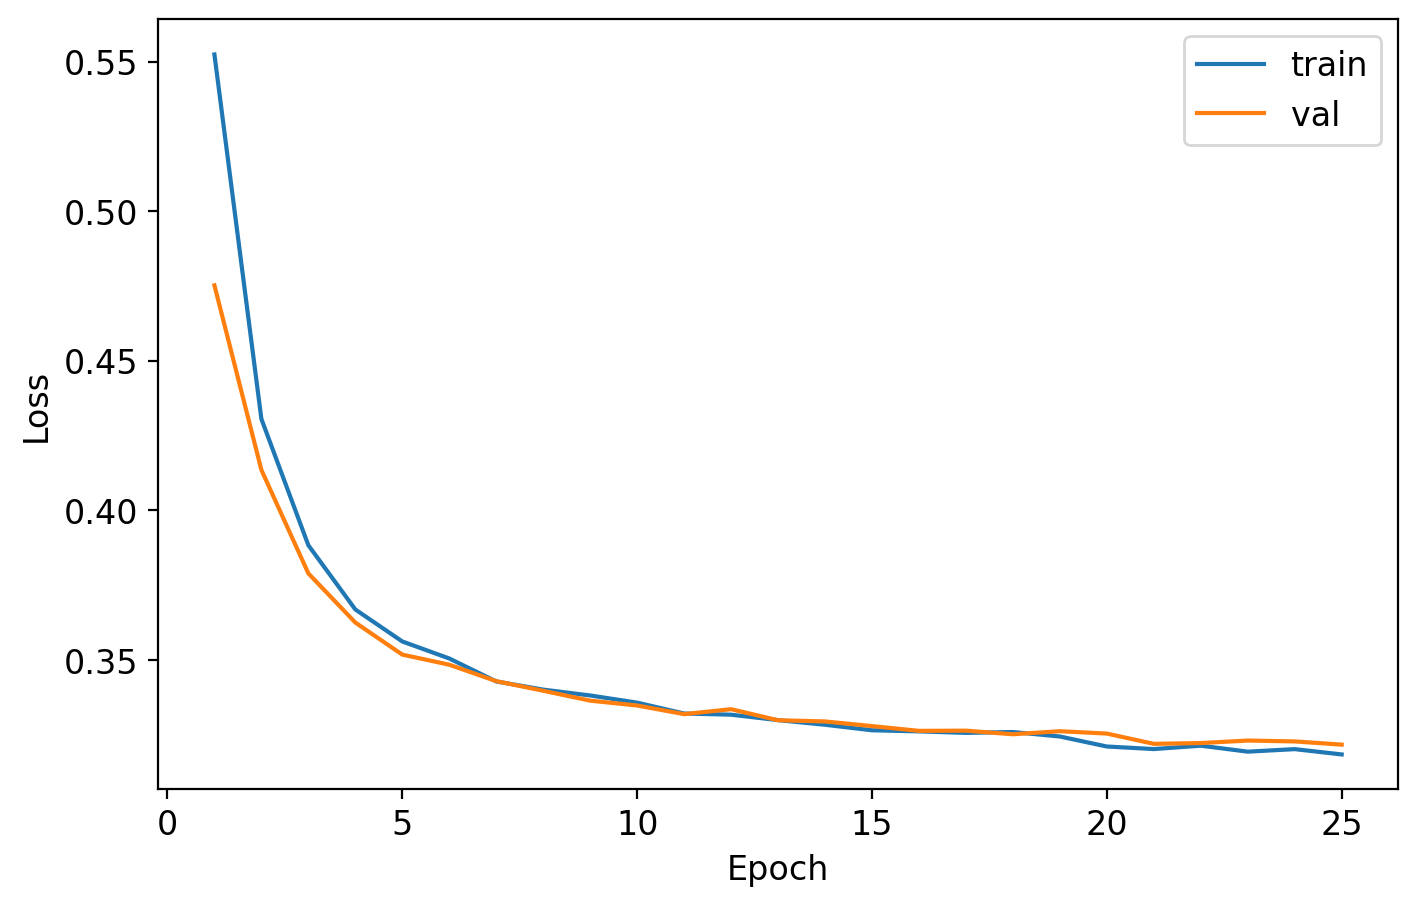

Epoch 25: train loss = 0.3184; valid loss = 0.3217


In [11]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 25, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
metrics_nn = bootstrap_metrics(y_true, y_pred, y_prob)

In [13]:
res = pd.DataFrame([{"model": "Logistic regression"} | metrics_lr, {"model": "CatBoost"} | metrics_cb, {"model": "LightGBM"} | metrics_lgbm, {"model": "TABMLP"} | metrics_nn])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,Logistic regression,0.9085±0.0044,0.6716±0.0116,0.8551±0.0051,0.7342±0.0142,0.6190±0.0142
1,CatBoost,0.9334±0.0036,0.7268±0.0106,0.8793±0.0046,0.7929±0.0126,0.6710±0.0139
2,LightGBM,0.9335±0.0036,0.7252±0.0106,0.8778±0.0047,0.7858±0.0129,0.6734±0.0137
3,TABMLP,0.9114±0.0044,0.6964±0.0113,0.8580±0.0053,0.7131±0.0136,0.6806±0.0140
